In [2]:
import warnings

warnings.filterwarnings("ignore")


from datetime import date, timedelta
from pypfopt import expected_returns
import pyfolio as pf
import ffn


import datetime
from empyrical.stats import  *

# 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pypfopt.expected_returns import returns_from_prices

import quandl
quandl.ApiConfig.api_key = 'fhbmNKX6oNP7PpFuZJNo'

# for downloading data 
from fredapi import Fred

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [16]:
from myPortfolioManagement.myData import get_stock_prices, get_sp500_tickers, get_fred_data
from myPortfolioManagement.myPerformanceAnalytics import alpha_beta_table

In [ ]:
# import stock prices 
#df_sp_stock_price = pd.read_csv('/Users/safishajjouz/Dropbox/Schonfeld_shared_folder/sp_prices.csv')
df = get_sp500_tickers()
df = df[df['Industry']!='Exchange Traded Fund']

# Set dates

start_date = '1995-01-01'
end_date = date.today() - timedelta(days=1)
end_date = end_date.strftime("%Y-%m-%d")
time_interval = 'monthly'


df_sp_stock_price = get_stock_prices(yahoo_tickers=df['Ticker'].to_list(),
                            start_date=start_date,
                            end_date=end_date, 
                            wide_format = True,
                            time_interval=time_interval)


df_bench = get_stock_prices(yahoo_tickers = ['^GSPC'], 
                 start_date = start_date,
                 end_date = date_end, 
                 time_interval = time_interval, 
                 num_cpus = 5) 

In [7]:
ret = returns_from_prices(df_sp_stock_price)
ret.index = pd.to_datetime(ret.index)
ret  = ret.resample('M').mean()
ret['year'] = pd.DatetimeIndex(ret.index).year
ret['month'] = pd.DatetimeIndex(ret.index).month

In [12]:
series_to_download = ['CPIAUCSL', # CPI all items #  
                     'USACPICORMINMEI'] #CPI ex-food and energy

# choose frequency 
freq = ['m', 'q', 'a'][0]
df = get_fred_data(fred_sumbol =series_to_download,  freq = freq)
df = df [ df.index>= start_date] 
df_inf = returns_from_prices(df)

<AxesSubplot:xlabel='Date'>

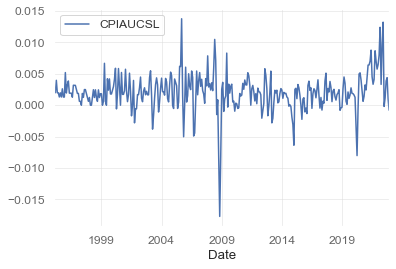

In [26]:
df_inf[['CPIAUCSL']].plot()

In [21]:
df_greeks = alpha_beta_table(ret.drop(['year', 'month'], axis = 1), returns_benchmark = df_inf[['CPIAUCSL']], 
                       my_date_col_name = 'Date', period='monthly')

TypeError: '>' not supported between instances of 'Timestamp' and 'numpy.int64'

In [ ]:
df_greeks.sort_values('beta', ascending = False)

In [ ]:
import pandas as pd 
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from finvizfinance.screener.overview import Overview

import plotly.express as px

In [ ]:
# for filtering: https://finviz.com/screener.ashx
foverview = Overview()
filters_dict = {'Index': 'S&P 500'}
foverview.set_filter(filters_dict=filters_dict)
df_stock_info = foverview.ScreenerView()

In [ ]:
df_greeks = df_greeks.reset_index().rename(columns = {'fund': 'Ticker'})

In [ ]:
df_stock_info = df_stock_info[['Ticker', 'Company', 'Sector']].merge(df_greeks, on = 'Ticker')

In [ ]:
df_stock_info = df_stock_info.rename(columns = {'beta':'inflation_beta'})

In [ ]:
df_stock_info.to_csv('/Users/safishajjouz/GitHub/myPortfolioManagement/stock_inf_sen.csv', index=False)